In [1]:
cd /Users/safishajjouz/GitHub/myPythonPackages

/Users/safishajjouz/GitHub/myPythonPackages


In [2]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myPerformanceAnalytics import *
from myPortfolioManagement.myPortfolioSelection import *
from myPortfolioManagement.myBacktesting import *

/Users/safishajjouz/opt/anaconda3/envs/myport_management_env/lib/python3.8/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [ ]:
### load Data 

In [3]:
file = '/Users/safishajjouz/GitHub/myPortfolioManagement/BBG_CommodityIndex.xlsx'

df_com_prices = pd.read_excel(file, sheet_name='USD_daily', skiprows = 6)
df_com_prices = df_com_prices.drop(['PX_VOLUME'], axis =1)
df_com_prices = df_com_prices.set_index('Date')
df_com_prices = df_com_prices.reindex(index=df_com_prices.index[::-1])
ret_comm = calculate_returns(df_com_prices)

## Working in progress: Functionality to adjust the chart so one can better see the fan charts when series are long

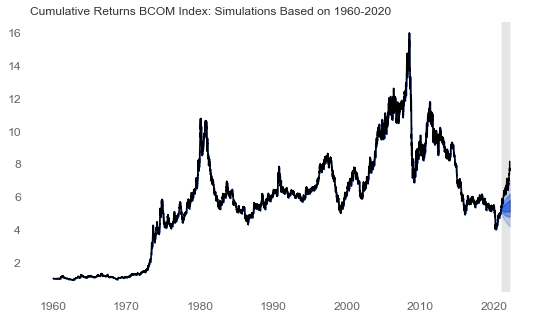

In [13]:
### create a fan chart 
fan_chart(returns = ret_comm['PX_LAST'], 
               weight_period = None,  ## this to bootstrap from specific regimes 
               out_of_sample_date = '2021-01-01', 
               n_sample = 1000,
               chart_title = 'Cumulative Returns BCOM Index: Simulations Based on 1960-2020' )


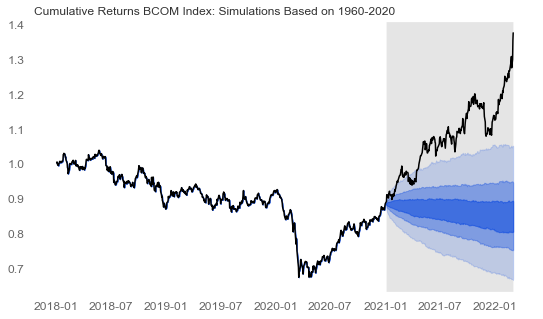

In [14]:
## this is just to see how the fan chart looks like 


fan_chart(returns = ret_comm['PX_LAST'][ret_comm['PX_LAST'].index>='2018-01-01'], 
               weight_period = None, 
               out_of_sample_date = '2021-01-01', 
               n_sample = 1000,
               chart_title = 'Cumulative Returns BCOM Index: Simulations Based on 1960-2020' )


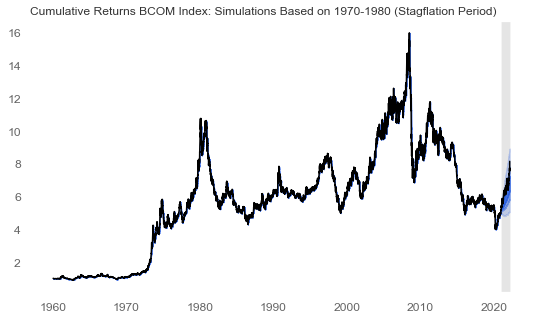

In [5]:
### create a fan chart based on the distribution of a specific period: Here from 1970 - 1980
fan_chart(returns = ret_comm['PX_LAST'],  
               weight_period = ['1970-01-01', '1980-01-01'], 
               out_of_sample_date = '2021-01-01', 
               n_sample = 1000,
               chart_title = 'Cumulative Returns BCOM Index: Simulations Based on 1970-1980 (Stagflation Period)' )

In [6]:
# get bootstrap stats 
bootstrap_stats(returns = ret_comm['PX_LAST'], 
                  returns_benchmark=None, 
                    rf = 0.02, 
                    periods = 252, 
                    n_sim = 1000)

bootstrap_stats took 85.948sec


,average_returns,volatility,sharpe,sortino,skew,comp
0,0.011041,0.137853,0.010266,0.004404,-0.312157,0.948835
1,0.011063,0.137862,0.010326,0.005729,-0.311500,0.953709
2,0.011121,0.137872,0.010596,0.005816,-0.309878,0.961647
3,0.011168,0.137873,0.011526,0.006683,-0.309833,0.962772
4,0.011312,0.137881,0.011562,0.007403,-0.309705,0.964276
...,...,...,...,...,...,...
875,0.057886,0.141451,0.330812,0.473437,-0.054139,30.621492
876,0.057927,0.141463,0.330923,0.474767,-0.053323,30.715062
877,0.058042,0.141467,0.331021,0.475384,-0.052229,30.890882
878,0.058078,0.141471,0.331517,0.476454,-0.050449,30.918974


In [7]:
port_perf = bootstrap_portfolio_performance(returns = ret_comm['PX_LAST'], 
                                returns_benchmark = None,
                                periods = 252,
                                rf = 0.02, 
                                out_of_sample_date = '2020-01-01',  
                                n_sim = 1000)

bootstrap_stats took 85.315sec
bootstrap_stats took 83.359sec
bootstrap_stats took 84.662sec
bootstrap_portfolio_performance took 253.362sec


In [8]:
ret_sp = download_returns(yahoo_tickers = ['SMT.L', 'DBC', '^GSPC'])

port_perf2 = bootstrap_portfolio_performance(returns = ret_comm['PX_LAST'], 
                                returns_benchmark = ret_sp['SMT.L'],
                                periods = 252, # this is for annualisation 
                                rf = 0.02, 
                                out_of_sample_date = '2020-01-01',  
                                n_sim = 1000)


bootstrap_stats took 1267.590sec
bootstrap_stats took 85.985sec
bootstrap_stats took 90.878sec
bootstrap_portfolio_performance took 1444.490sec


In [9]:
port_perf2[0]

,in_sample,out_of_sample,all_sample
average_returns,0.032599,0.192938,0.039236
volatility,0.145117,0.155757,0.145572
sharpe,0.162905,1.036448,0.189392
sortino,0.216450,1.475759,0.268400
skew,-0.162297,-0.657860,-0.185040
comp,5.269652,0.526240,8.492342
alpha,-0.991274,-0.988440,-0.991087
beta,0.061235,0.090691,0.063625


In [10]:
port_perf2[1]

,average_returns_in_sample,volatility_in_sample,sharpe_in_sample,sortino_in_sample,skew_in_sample,comp_in_sample,alpha_in_sample,beta_in_sample,average_returns_out_sample,volatility_out_sample,...,alpha_out_sample,beta_out_sample,average_returns,volatility,sharpe,sortino,skew,comp,alpha,beta
0,0.006064,0.143187,-0.017000,-0.017298,-0.301244,0.400378,-0.992084,0.043217,0.040622,0.146446,...,-0.990235,0.062084,0.012991,0.143519,0.024187,0.017370,-0.310424,0.964636,-0.991904,0.047323
1,0.006260,0.143193,-0.014333,-0.017287,-0.299381,0.434729,-0.992084,0.043300,0.040815,0.146472,...,-0.990219,0.062500,0.013217,0.143531,0.024403,0.018052,-0.310328,0.968318,-0.991899,0.047358
2,0.006511,0.143193,-0.013724,-0.017194,-0.298351,0.439930,-0.992075,0.043404,0.041557,0.146531,...,-0.990218,0.062538,0.013242,0.143558,0.024497,0.018158,-0.310158,0.972253,-0.991898,0.047364
3,0.006707,0.143198,-0.013267,-0.016234,-0.296910,0.447666,-0.992074,0.043412,0.041654,0.146536,...,-0.990215,0.062622,0.013387,0.143561,0.024960,0.019713,-0.309412,0.982871,-0.991898,0.047449
4,0.006758,0.143205,-0.012214,-0.016228,-0.296479,0.449634,-0.992072,0.043547,0.042539,0.146566,...,-0.990206,0.062754,0.013469,0.143567,0.025386,0.020553,-0.308989,0.997004,-0.991894,0.047645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,0.058575,0.147011,0.340671,0.469399,-0.036329,17.621205,-0.990435,0.078982,0.351680,0.165006,...,-0.986510,0.118844,0.064711,0.147468,0.351967,0.512929,-0.066597,27.342866,-0.990276,0.079996
876,0.058737,0.147011,0.341590,0.470263,-0.036028,17.773635,-0.990433,0.079077,0.353278,0.165039,...,-0.986497,0.118970,0.064853,0.147486,0.352135,0.513946,-0.066288,27.477790,-0.990265,0.080013
877,0.058847,0.147013,0.341798,0.471203,-0.035857,17.792258,-0.990425,0.079096,0.353293,0.165152,...,-0.986492,0.119079,0.065006,0.147490,0.352731,0.514138,-0.065897,27.659225,-0.990258,0.080071
878,0.058997,0.147025,0.343490,0.471231,-0.035029,17.854279,-0.990424,0.079116,0.353442,0.165167,...,-0.986477,0.119276,0.065079,0.147491,0.353445,0.514600,-0.065880,27.821376,-0.990257,0.080080
